### Exploratory Data Analysis (EDA)
The goal of this notebook is to 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)


from src.preprocessing import preprocess_data

file_path = r"../data/RA_Dataset.xlsx"
output_path = r"../data/RA_dataset_cleaned.csv"

df_cleaned=preprocess_data(file_path)
df_cleaned.to_csv(output_path, index=False)


Dropping columns with > 50% missing values: smoking, tjc_28, sjc_28, vas


Variables with more than 50% missing values were identified and excluded from further analysis prior to modeling. The table below shows these variables and their percentage of missingness.
Tjc28, and scj28 are excluded also because they are highly correlated to DAS28, that has less missingness.

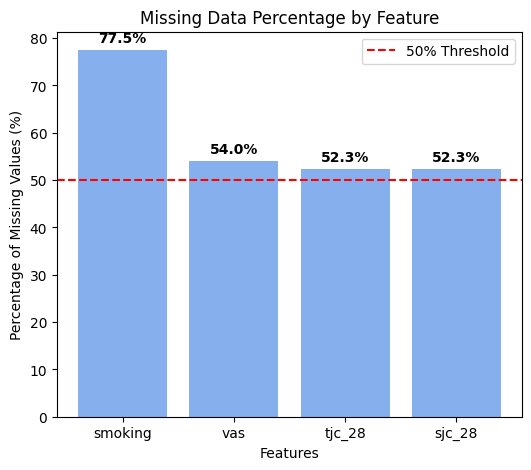

In [3]:
from src.preprocessing import handle_categorical_missing, load_data

df_raw = load_data(file_path)
handle_categorical_missing(df_raw)

missing_percent = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
high_missing = missing_percent[missing_percent > 50]

plt.figure(figsize=(6, 5))
graph = plt.bar(high_missing.index.to_numpy(), high_missing.to_numpy(), color="#85b0ed")

for p in graph:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    plt.text(
        x,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        weight="bold"
    )
plt.axhline(50, color='red', linestyle='--', label='50% Threshold')
plt.title('Missing Data Percentage by Feature')
plt.xlabel('Features')
plt.ylabel('Percentage of Missing Values (%)')
plt.legend()
plt.show()

#### Dataset Overview

In [187]:
df_cleaned.shape

(228, 46)

In [ ]:
df_cleaned.head(10)

In [ ]:
df_cleaned.columns.to_list()

In [5]:
cols_to_drop = ['year_of_diagnosis', 'crp', 'crp_upper_limit', 'source']
df_eda = df_cleaned.drop(columns=cols_to_drop)
df_eda.head()

,patient_id,gender,rf_status,anti_ccp_status,comorbidities,visit_date,visit_type,esr,das28_score,csdmard_name,...,comorb_gastrointestinal_hepatic,comorb_malignancy,comorb_musculoskeletal,comorb_neurologic_psychiatric,comorb_autoimmune_other,comorbidity_count,csdmard_use,b_ts_dmard_use,steroid_use,treatment_count
0,RA001,1,0,0,"depression,hypothyroidism",2017-12-18,Baseline,24.0,4.07,Azathioprine,...,0,0,0,1,0,2,1,1,0,3
1,RA001,1,0,0,"depression,hypothyroidism",2018-03-20,Follow-up,NaN,4.81,Hydroxychloroquine,...,0,0,0,1,0,2,1,0,0,2
2,RA001,1,0,0,"depression,hypothyroidism",2018-09-25,Follow-up,NaN,3.66,none,...,0,0,0,1,0,2,0,1,0,1
4,RA002,1,0,0,,2023-10-27,Baseline,3.0,3.45,Leflunomide,...,0,0,0,0,0,0,1,1,0,3
5,RA002,1,0,0,,2024-01-30,Follow-up,6.0,2.20,Hydroxychloroquine,...,0,0,0,0,0,0,1,1,0,2


In [51]:
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
gender,228.0,0.802632,0.0,1.0,1.0,1.0,1.0,0.398888
rf_status,225.0,0.542222,0.0,0.0,1.0,1.0,1.0,0.499325
anti_ccp_status,225.0,0.6,0.0,0.0,1.0,1.0,1.0,0.49099
visit_date,228,2020-10-18 14:37:53.684210,2015-03-03 00:00:00,2018-12-13 06:00:00,2020-09-11 00:00:00,2022-12-29 12:00:00,2025-12-02 00:00:00,NaN
esr,192.0,26.677083,2.0,14.0,22.0,35.0,105.0,19.707014
das28_score,134.0,3.713657,1.05,2.845,3.595,4.7225,6.8,1.273935
mtx_use,228.0,0.530702,0.0,0.0,1.0,1.0,1.0,0.500155
mtx_dose,228.0,8.33114,0.0,0.0,8.75,15.0,25.0,8.647591
steroid_dose,228.0,4.506579,0.0,0.0,0.0,5.0,500.0,33.133939
flare_event,228.0,0.482456,0.0,0.0,0.0,1.0,1.0,0.500792


In [ ]:
df_eda.info(verbose=True, show_counts=True)

#### Missingness

In [89]:
missing_count = df_eda.isnull().sum()
missing_percentage = (df_eda.isnull().mean() * 100).round(1)

#Summary Table
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_percentage
    }).sort_values(by='missing_percentage', ascending=False)

missing_table[missing_table['missing_percentage'] > 0]

,missing_count,missing_percentage
das28_change,95,41.7
das28_score,94,41.2
crp_normalized,66,28.9
esr,36,15.8
rf_status,3,1.3
anti_ccp_status,3,1.3
disease_duration,2,0.9


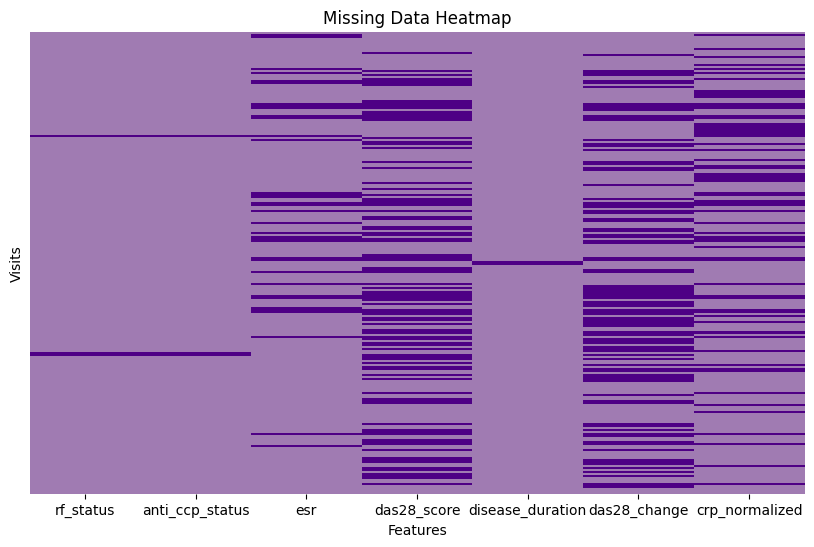

In [95]:
#Missingness Visualization
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#A07BB2FF", "#4e0085"])


#Heatmap of missing values
missing_cols = df_eda.columns[df_eda.isnull().any()]
plt.figure(figsize=(10, 6))
sns.heatmap(df_eda[missing_cols].isnull(), cbar=False, cmap=cmap, yticklabels=False)
plt.title('Missing Data Heatmap')
plt.xlabel('Features')
plt.ylabel('Visits')
plt.show()


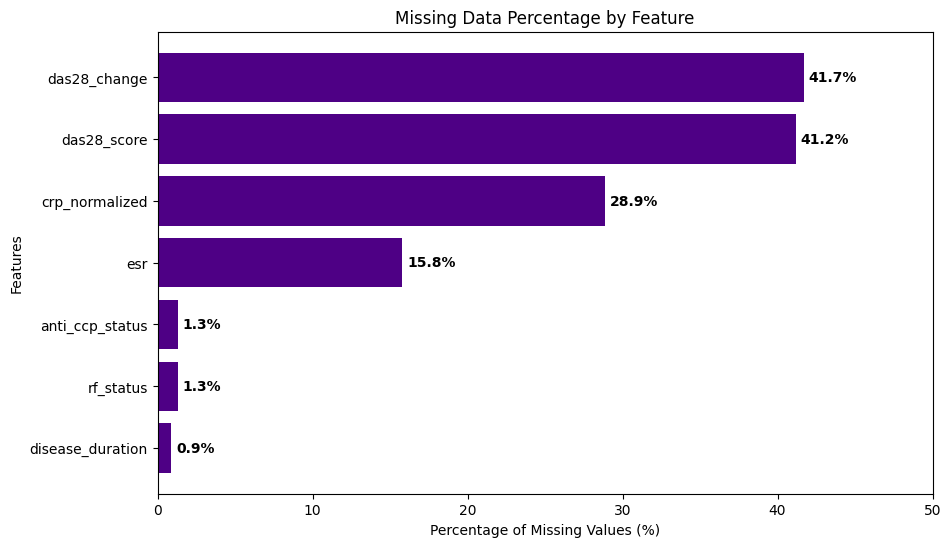

In [121]:
#Barplot of missing values
missing_plot = (missing_table[missing_table['missing_percentage'] > 0]
                .sort_values(by='missing_percentage', ascending=True))

plt.figure(figsize=(10, 6))
graph = plt.barh(missing_plot.index, missing_plot['missing_percentage'], color='#4e0085')

for p in graph:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    plt.text(
        width + 0.3,   
        y,
        f"{width:.1f}%",
        va="center",
        weight="bold"
    )

plt.title('Missing Data Percentage by Feature')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.xlim(0, 50)
plt.show()


In [ ]:
crp_counts = pd.crosstab(df_eda['crp_missing'], df_eda['target_flare_next'], 
            rownames=['CRP missing'], colnames=['Flare next visit'])


crp_percent = pd.crosstab(df_eda["crp_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["CRP missing"], colnames=["Flare next visit"]).round(2)

display(crp_counts)
display(crp_percent)

In [ ]:
esr_counts = pd.crosstab(df_eda['esr_missing'], df_eda['target_flare_next'], 
            rownames=['ESR missing'], colnames=['Flare next visit'])


esr_percent = pd.crosstab(df_eda["esr_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["ESR missing"], colnames=["Flare next visit"]).round(2)

display(esr_counts)
display(esr_percent)

In [ ]:
df_eda['das28_missing'] = df_eda['das28_change'].isnull().astype(int)

das28_counts = pd.crosstab(df_eda['das28_missing'], df_eda['target_flare_next'], 
            rownames=['DAS28 Missing'], colnames=['Flare next visit'])


das28_percent = pd.crosstab(df_eda["das28_missing"], df_eda["target_flare_next"], normalize="index", 
            rownames=["DAS28 Missing"], colnames=["Flare next visit"]).round(2)

display(das28_counts)
display(das28_percent)

### Does feature missingness appear to affect the target variable?

<span style="color: green;">**CRP**</span>  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When CRP is present (0) : 41%  
- When CRP is not present (1): 36%  
- Difference: 5%. 


This small difference suggests that CRP missingness is not strongly associated with the outcome and is unlikely to represent highly informative missingness.



<span style="color: cyan;">**ESR**</span>   
For ESR, visits with missing values showed a lower proportion of next-visit flare compared with visits where ESR was available.  
- When ESR is present (0) and available 80/192: 42%  
- When ESR is not present (1) and missing 10/36: 28%  
- Difference: 14%  

This more noticeable difference suggests that ESR missingness may carry some information and may not be completely random, although the number of visits with missing ESR was smaller.
  
<span style="color: purple;">**DAS28 score**</span>   
Because DAS28_score and DAS28_change are highly correlated, only das28_score missingness percentage was evaluated.  
The proportion of next-visit flare was similar between visits with available and missing values.  
- When DAS28 is present (0), and available 55/133: 41%  
- When DAS28 is not present (1) and available 35/95: 37%  
- Difference: 4%   

This small difference suggests that DAS28 score missingness is not strongly associated with the outcome.

### Target Analysis


In [8]:
# Percentages of target variable
df_eda["target_flare_next"].value_counts(normalize=True, dropna=False) * 100

target_flare_next
0    60.526316
1    39.473684
Name: proportion, dtype: float64

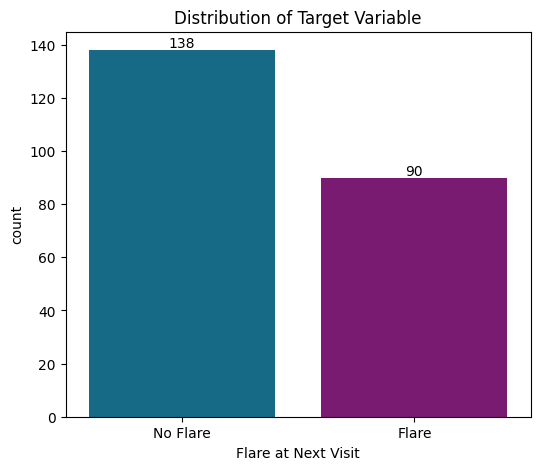

In [33]:
# Counts of target variable
plt.figure(figsize=(6, 5))
graph = sns.countplot(x='target_flare_next', data=df_eda, 
                      hue= 'target_flare_next', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Flare at Next Visit')
plt.xticks(ticks=[0, 1], labels=['No Flare', 'Flare'])


for p in graph.patches: 
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

The target variable 'flare_next_visit' showed a small imbalance between Flare and no Flare events.

### Visits per patient

In [37]:
#visits per patient
visits_per_patient = df_eda.groupby('patient_id').size()

#average visits per patient
visits_per_patient.describe()

count    70.000000
mean      3.257143
std       2.204644
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max      13.000000
dtype: float64

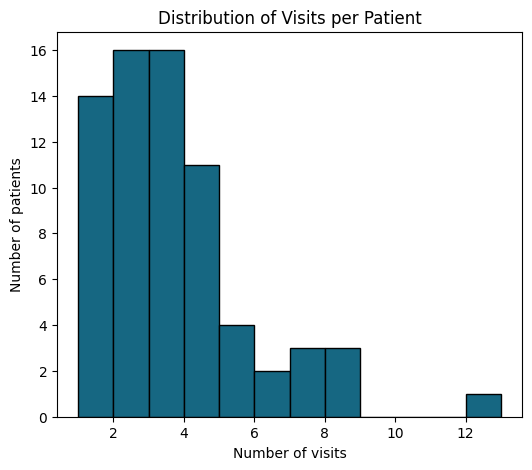

In [50]:
plt.figure(figsize=(6, 5))
graph = plt.hist(visits_per_patient, bins=12, color = "#166782FF", edgecolor='black')
plt.title('Distribution of Visits per Patient')
plt.xlabel('Number of visits')
plt.ylabel('Number of patients')
plt.show()

The number of visits per patient was examined to better characterize the longitudinal structure of the dataset. A total of **70 patients** were included, with a mean of **3.26 visits per patient** (SD = **2.20**) and a median of **3 visits**. Most patients contributed between **2 and 4 visits**, although follow-up was unequal across the cohort, ranging from **1 to 13 visits**. This pattern is consistent with real-world longitudinal clinical data, where the number of recorded visits varies between patients.

### Univariate Analysis

Continuous variables


In [66]:
df_eda['das28_score'].describe()

count    133.000000
mean      -0.191053
std        1.028644
min       -3.430000
25%       -0.510000
50%        0.000000
75%        0.000000
max        3.100000
Name: das28_change, dtype: float64

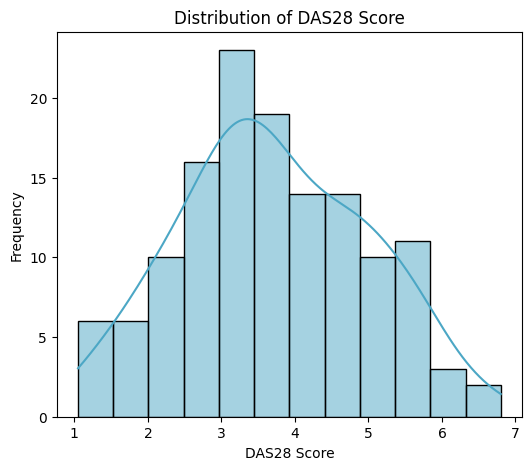

In [71]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_eda.dropna(subset=['das28_score']),
    x='das28_score',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of DAS28 Score')
plt.xlabel('DAS28 Score')
plt.ylabel('Frequency')
plt.show()

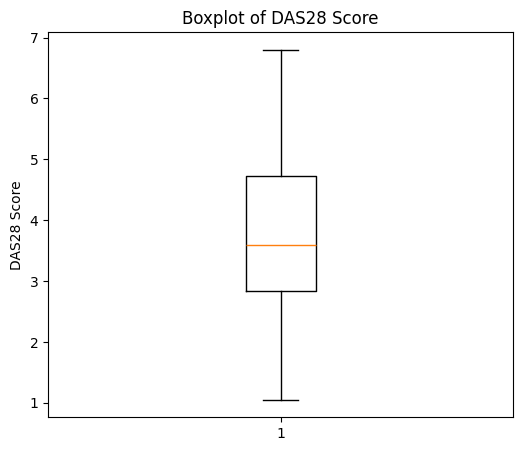

In [78]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_eda['das28_score'].dropna(), vert=True)
plt.title('Boxplot of DAS28 Score')
plt.ylabel('DAS28 Score')
plt.show()

In [79]:
df_eda['crp_normalized'].describe()

count    162.000000
mean       1.528625
std        3.319443
min        0.020000
25%        0.250000
50%        0.560000
75%        1.500000
max       32.000000
Name: crp_normalized, dtype: float64

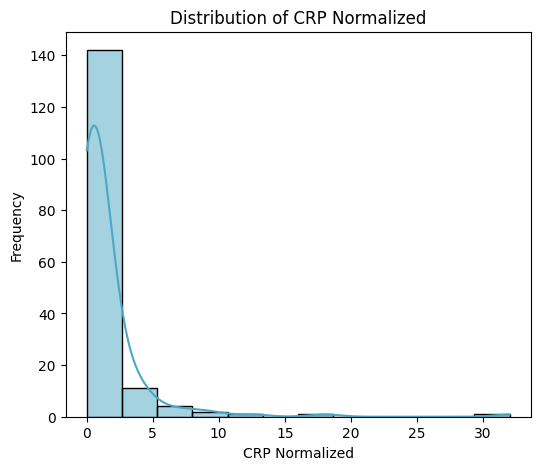

In [80]:
plt.figure(figsize=(6, 5))
sns.histplot(
    data=df_eda.dropna(subset=['crp_normalized']),
    x='crp_normalized',
    bins=12,
    color="#4CA7C5FF",
    kde=True,
    edgecolor='black'
)
plt.title('Distribution of CRP Normalized')
plt.xlabel('CRP Normalized')
plt.ylabel('Frequency')
plt.show()

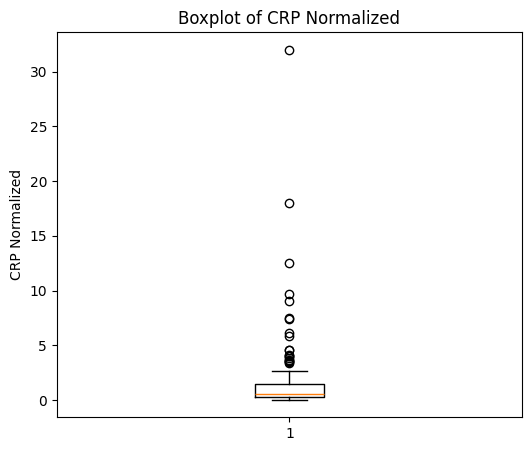

In [83]:
plt.figure(figsize=(6, 5))
plt.boxplot(x=df_eda['crp_normalized'].dropna(), vert=True)
plt.title('Boxplot of CRP Normalized')
plt.ylabel('CRP Normalized')
plt.show()

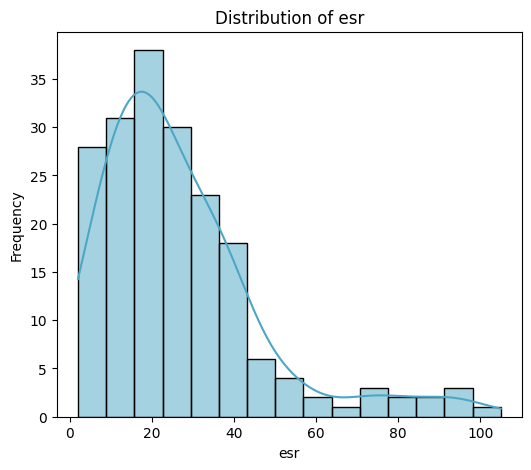

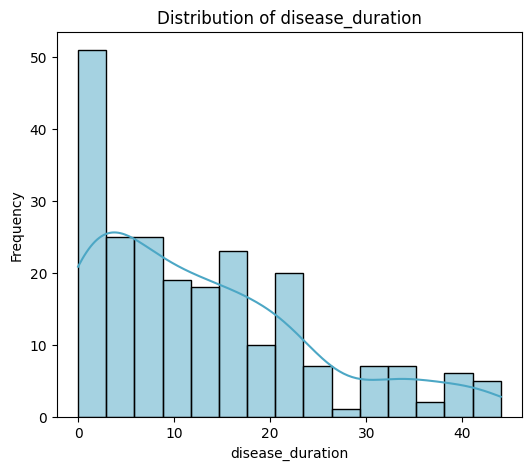

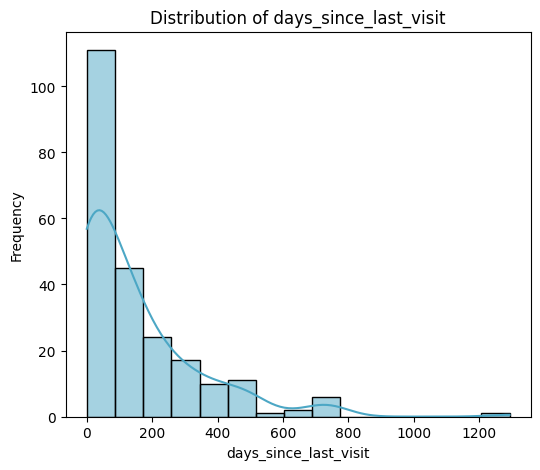

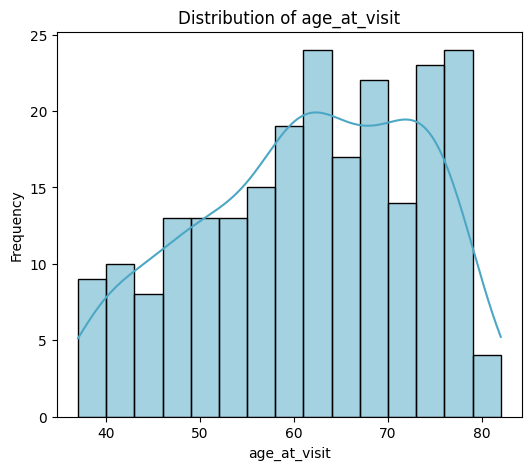

In [87]:
continuous_variables = [
                'esr',
                'disease_duration',
                'days_since_last_visit', 
                'age_at_visit'
]

for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    sns.histplot(
        data=df_eda.dropna(subset=[col]),
        x=col,
        bins=15,
        color="#4CA7C5FF",
        kde=True,
        edgecolor='black'
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

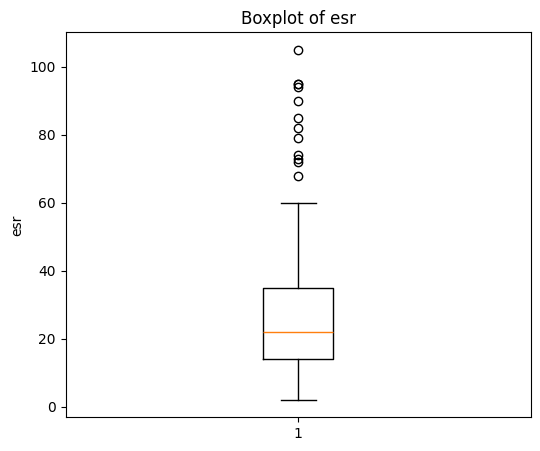

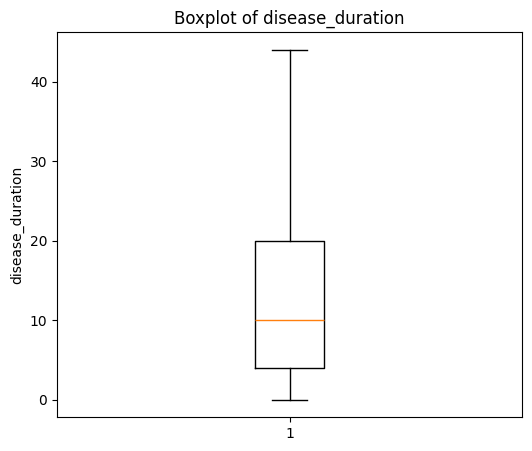

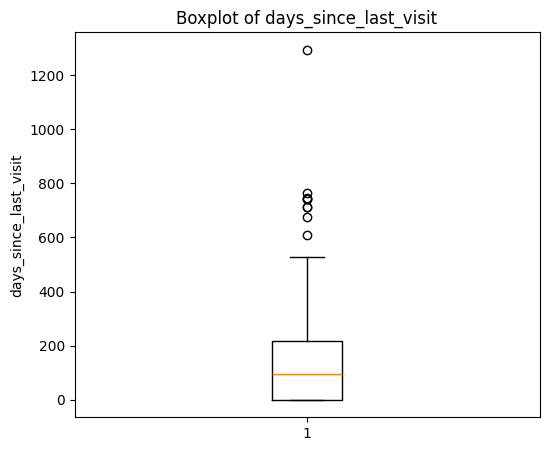

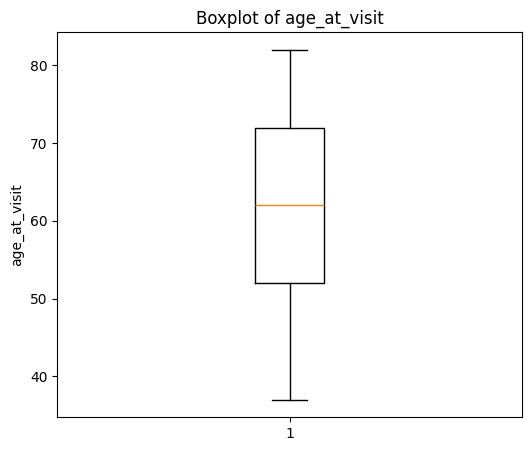

In [89]:
for col in continuous_variables:
    plt.figure(figsize=(6, 5))
    plt.boxplot(x=df_eda[col].dropna(), vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

In [86]:
df_eda['mtx_dose'].value_counts().sort_index()

mtx_dose
0.0     108
5.0       2
7.5       4
10.0     22
12.0      1
12.5      2
15.0     44
17.5      3
20.0     32
25.0     10
Name: count, dtype: int64

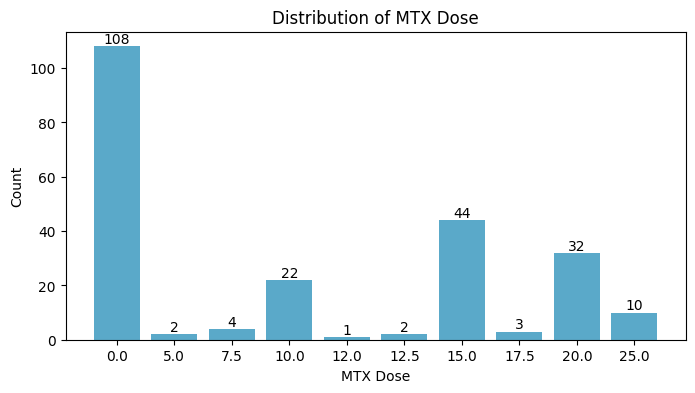

In [105]:
dose_counts = df_eda["mtx_dose"].value_counts().sort_index()
x_labels = dose_counts.index.astype(str).to_list()
y_counts = dose_counts.to_numpy(dtype=float)

plt.figure(figsize=(8,4))
bars = plt.bar(x_labels, y_counts, color="#5aa9c9")
plt.title("Distribution of MTX Dose")
plt.xlabel("MTX Dose")
plt.ylabel("Count")

for b in bars: 
    height = b.get_height()
    plt.text(
        b.get_x() + b.get_width()/2,
        height +1,
        f'{int(height)}', 
        ha = 'center'
    )

plt.show()

In [92]:
df_eda['steroid_dose'].value_counts().sort_index()

steroid_dose
0.0      133
2.0        4
2.5       11
4.0       19
5.0       24
6.0       15
7.5       10
8.0        2
10.0       6
15.0       1
20.0       2
500.0      1
Name: count, dtype: int64

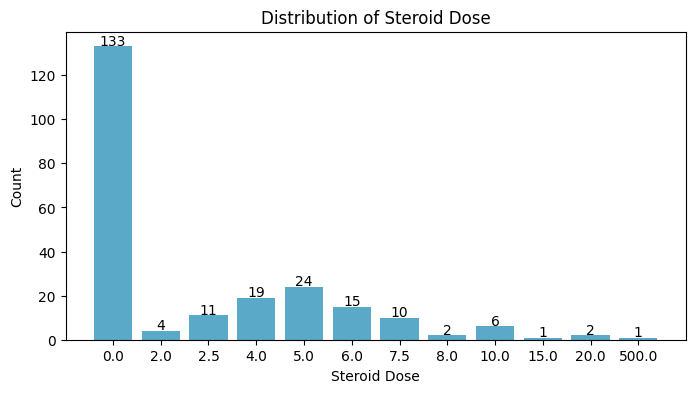

In [106]:
dose_counts = df_eda["steroid_dose"].value_counts().sort_index()

x_labels = dose_counts.index.astype(str).tolist()
y_counts = dose_counts.to_numpy(dtype=float)

plt.figure(figsize=(8, 4))
bars = plt.bar(x_labels, y_counts, color="#5aa9c9")

plt.title("Distribution of Steroid Dose")
plt.xlabel("Steroid Dose")
plt.ylabel("Count")

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2,
    h + 0.5,
    f"{int(h)}",
    ha="center")

plt.show()

Categorical variables

In [107]:
df_eda['gender'].value_counts()

gender
1    183
0     45
Name: count, dtype: Int64

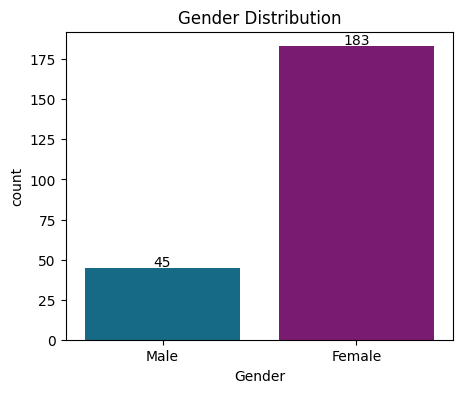

In [114]:
plt.figure(figsize=(5, 4))
graph = sns.countplot(x='gender', data=df_eda, hue = 'gender', palette= ["#047398", "#880c7e"], legend=False)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.xticks(ticks=[0,1], labels= ['Male', 'Female'] )

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
    
plt.show()

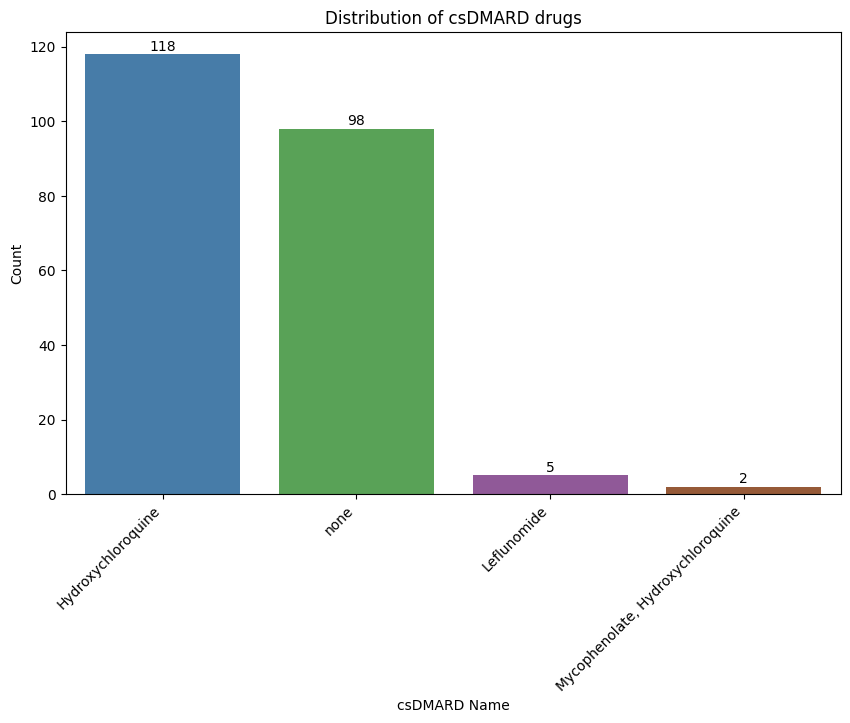

In [133]:
drug_order = df_eda["csdmard_name"].value_counts(dropna=False).head(4).index
plt.figure(figsize=(10, 6))
graph = sns.countplot(x='csdmard_name', data=df_eda, order= drug_order, hue='csdmard_name', palette= sns.color_palette("Set1"), legend=False)
plt.title('Distribution of csDMARD drugs')
plt.xlabel('csDMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

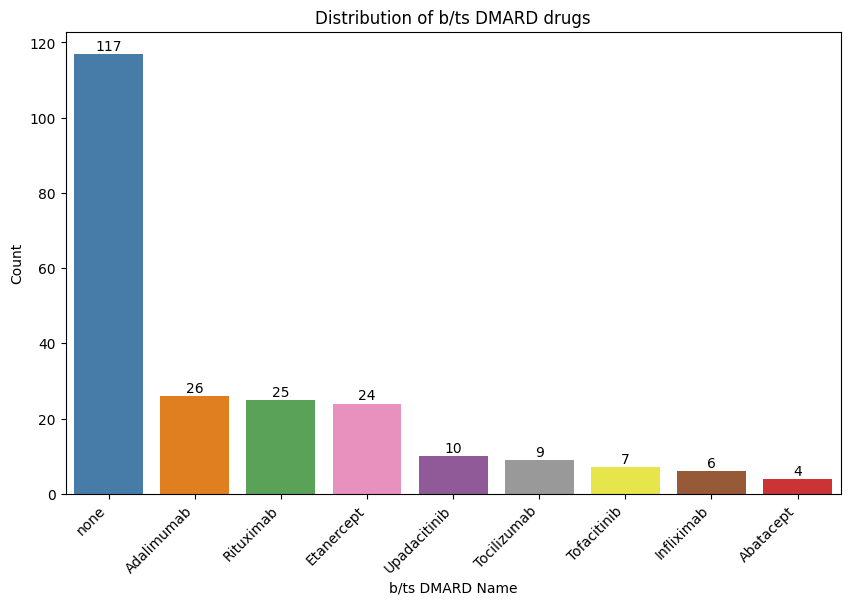

In [129]:
drug_order = df_eda["b_ts_dmard_name"].value_counts(dropna=False).index

plt.figure(figsize=(10, 6))
graph = sns.countplot(x='b_ts_dmard_name', data=df_eda, order= drug_order, hue='b_ts_dmard_name', palette= sns.color_palette("Set1"), legend=False)
plt.title('Distribution of b/ts DMARD drugs')
plt.xlabel('b/ts DMARD Name')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

for p in graph.patches:
    height = p.get_height()
    graph.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha='center'      
    )
plt.show()

In [152]:
comorb_cols = [
    'comorb_cardiovascular', 
    'comorb_metabolic_endocrine', 
    'comorb_respiratory', 
    'comorb_renal_urological',
    'comorb_gastrointestinal_hepatic',
    'comorb_malignancy',
    'comorb_musculoskeletal',
    'comorb_neurologic_psychiatric',
    'comorb_autoimmune_other'
]

comorb_label_map = {
    "comorb_cardiovascular": "Cardiovascular",
    "comorb_metabolic_endocrine": "Metabolic / Endocrine",
    "comorb_respiratory": "Respiratory",
    "comorb_renal_urological": "Renal / Urological",
    "comorb_gastrointestinal_hepatic": "Gastrointestinal / Hepatic",
    "comorb_malignancy": "Malignancy",
    "comorb_musculoskeletal": "Musculoskeletal",
    "comorb_neurologic_psychiatric": "Neurologic / Psychiatric",
    "comorb_autoimmune_other": "Autoimmune / Other"
}


patient_comorb = df_eda.groupby('patient_id')[comorb_cols].max()
comorb_counts = patient_comorb.sum().sort_values(ascending = False)
comorb_counts_named = comorb_counts.rename(index=comorb_label_map)


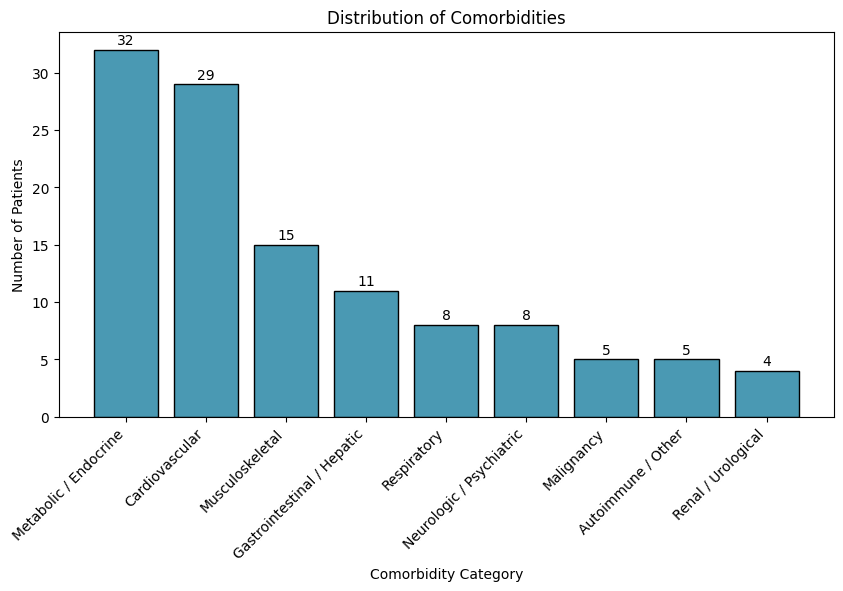

In [159]:
x_labels = comorb_counts_named.index.astype(str).to_list()
y_counts = comorb_counts_named.to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
graph = plt.bar(
    x_labels,
    y_counts,
    color="#4A99B3FF",
    edgecolor="black"
)
plt.title("Distribution of Comorbidities")
plt.xlabel("Comorbidity Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha="right")

for p in graph: 
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width() / 2,
        height + 0.2,
        f"{int(height)}",
        ha='center', 
        va='bottom'      
    )
plt.show()

In [160]:
df_eda['treatment_decision'].value_counts(normalize=True, dropna=False) * 100


treatment_decision
no_decision    30.701754
stable         25.877193
escalation     23.684211
tapering       11.842105
switch          7.894737
Name: proportion, dtype: float64

In [161]:
df_eda['switch_reason'].value_counts(normalize=True, dropna=False) * 100

switch_reason
no_switch        92.982456
Inefficacy        6.578947
Adverse event     0.438596
Name: proportion, dtype: float64

In [27]:
df_cleaned['days_since_last_flare_bin'] = pd.cut(
    df_cleaned['days_since_last_flare'],
    bins=[0, 30, 90, 180, 365, 1000]
)

pd.crosstab(
    df_cleaned['days_since_last_flare_bin'],
    df_cleaned['target_flare_next'],
    normalize='index'
)

df_cleaned['days_since_last_flare_bin'].value_counts(dropna=False)

days_since_last_flare_bin
NaN                157
(30.0, 90.0]        19
(180.0, 365.0]      19
(90.0, 180.0]       17
(365.0, 1000.0]     12
(0.0, 30.0]          4
Name: count, dtype: int64

In [15]:
pd.crosstab(df_cleaned['treatment_decision'], df_cleaned['target_flare_next'], normalize='index')


target_flare_next,0,1
treatment_decision,,
Escalation,0.518519,0.481481
Stable,0.627119,0.372881
Switch,0.722222,0.277778
Tapering,0.555556,0.444444


In [23]:
df_cleaned.loc[df_cleaned['treatment_decision'] == 'Switch', 'switch_reason'].value_counts(dropna=False)

switch_reason
Inefficacy       15
no_switch         2
Adverse event     1
Name: count, dtype: int64

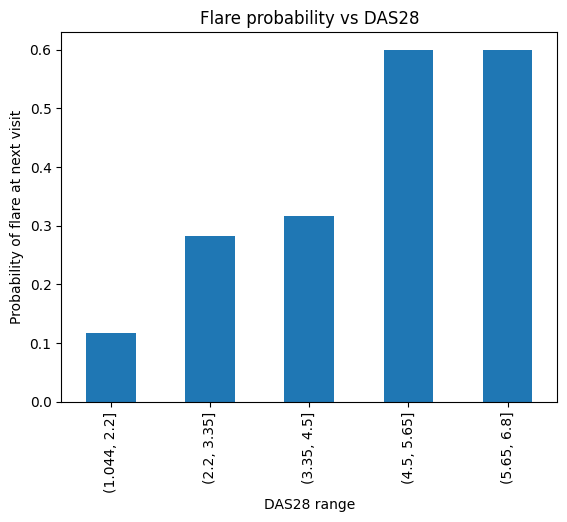

In [16]:
import matplotlib.pyplot as plt


df_cleaned['das28_bin'] = pd.cut(df_cleaned['das28_score'], bins=5)
flare_rate = df_cleaned.groupby('das28_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("DAS28 range")
plt.title("Flare probability vs DAS28")
plt.show()


In [ ]:
df_cleaned['crp_bin'] = pd.cut(df_cleaned['crp_normalized'], bins=5)
flare_rate = df_cleaned.groupby('crp_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("CRP range")
plt.title("Flare probability vs CRP")
plt.show()

In [ ]:
df_cleaned['esr_bin'] = pd.cut(df_cleaned['esr'], bins=5)
flare_rate = df_cleaned.groupby('esr_bin')['target_flare_next'].mean()
flare_rate.plot(kind='bar')

plt.ylabel("Probability of flare at next visit")
plt.xlabel("ESR range")
plt.title("Flare probability vs ESR")
plt.show()

In [19]:
pd.crosstab(
    df_cleaned['previous_flare'],
    df_cleaned['target_flare_next'],
    normalize='index'
)


target_flare_next,0,1
previous_flare,,
0,0.664286,0.335714
1,0.511364,0.488636


In [20]:

pd.crosstab(
    df_cleaned['flare_event'],
    df_cleaned['steroid_use'],
    normalize='index'
)


steroid_use,0,1
flare_event,,
0,0.669492,0.330508
1,0.490909,0.509091


In [21]:
df_cleaned['baseline_visit'] = (df_cleaned['visit_type'] == 'Baseline').astype(int)
pd.crosstab(
    df_cleaned['baseline_visit'],
    df_cleaned['target_flare_next'],
    normalize='index'
)

target_flare_next,0,1
baseline_visit,,
0,0.588608,0.411392
1,0.642857,0.357143


In [ ]:
# Boxplots of numeric predictors vs flare_event
numeric_cols = ['age_at_visit', 'das28_score', 'crp', 'esr', 'steroid_dose']
for col in numeric_cols:
    sns.boxplot(x='flare_event', y=col, data=df_cleaned)
    plt.title(f"{col} vs flare_event (raw)")
    plt.show()

# Bar plots for categorical predictors
categorical_cols = ['gender', 'rf_status', 'anti_ccp_status', 'csdmard_name', 'b_ts_dmard_name']
for col in categorical_cols:
    sns.countplot(x=col, hue='flare_event', data=df_cleaned)
    plt.title(f"{col} vs flare_event (raw)")
    plt.show()